In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Loan_Default.csv")

In [3]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [4]:
df.shape

(148670, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [6]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [7]:
missing = df.isnull().sum()

In [8]:
missing_pct = (missing  / len(df) * 100).round(2)
missing_pct = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_pct[missing_pct['Missing Count'] > 0].sort_values('Missing %', ascending = False)
missing_df.to_string()

'                           Missing Count  Missing %\nUpfront_charges                    39642      26.66\nInterest_rate_spread               36639      24.64\nrate_of_interest                   36439      24.51\ndtir1                              24121      16.22\nproperty_value                     15098      10.16\nLTV                                15098      10.16\nincome                              9150       6.15\nloan_limit                          3344       2.25\napprov_in_adv                        908       0.61\nsubmission_of_application            200       0.13\nage                                  200       0.13\nloan_purpose                         134       0.09\nNeg_ammortization                    121       0.08\nterm                                  41       0.03'

### Handling Missing Values

In [9]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Filling missing values...")

# Impute numerical columns with their median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in numerical column '{col}' with median: {median_val}")

# Impute categorical columns with their mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple values, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
display(df.isnull().sum().to_frame(name='Null Count'))

Filling missing values...
Filled missing values in numerical column 'rate_of_interest' with median: 3.99
Filled missing values in numerical column 'Interest_rate_spread' with median: 0.3904
Filled missing values in numerical column 'Upfront_charges' with median: 2596.45
Filled missing values in numerical column 'term' with median: 360.0
Filled missing values in numerical column 'property_value' with median: 418000.0
Filled missing values in numerical column 'income' with median: 5760.0
Filled missing values in numerical column 'LTV' with median: 75.13586957
Filled missing values in numerical column 'dtir1' with median: 39.0
Filled missing values in categorical column 'loan_limit' with mode: cf
Filled missing values in categorical column 'approv_in_adv' with mode: nopre


/tmp/ipykernel_5767/1113199664.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_5767/1113199664.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Filled missing values in categorical column 'loan_purpose' with mode: p3
Filled missing values in categorical column 'Neg_ammortization' with mode: not_neg
Filled missing values in categorical column 'age' with mode: 45-54
Filled missing values in categorical column 'submission_of_application' with mode: to_inst

Missing values after imputation:


,Null Count
ID,0
year,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,0
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


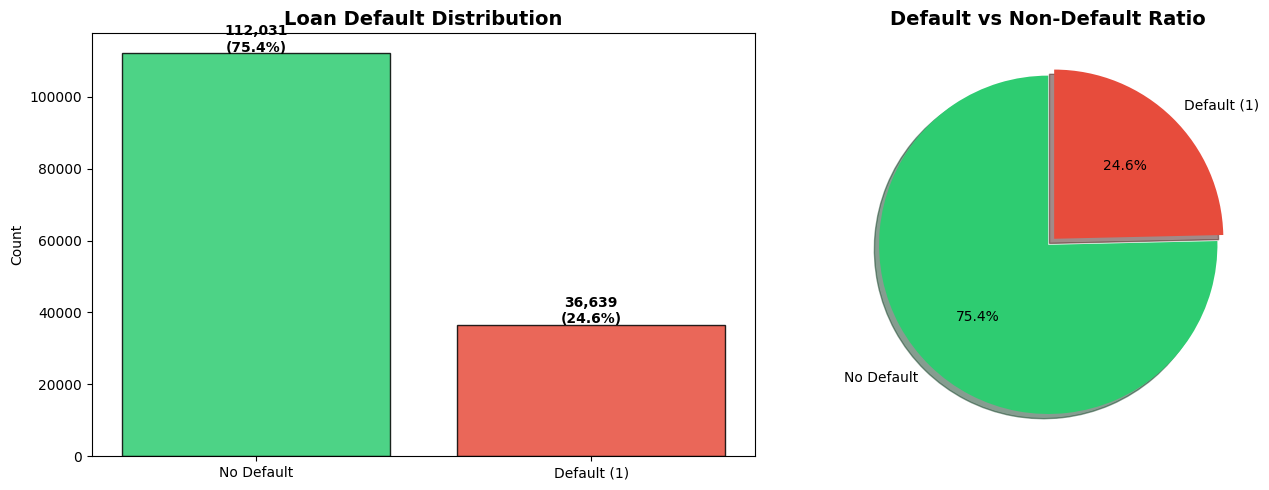

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Count plot
counts = df['Status'].value_counts()
labels = ['No Default', 'Default (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Loan Default Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
  axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, shadow = True, explode = (0, 0.05))
axes[1].set_title('Default vs Non-Default Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5767/2283218506.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


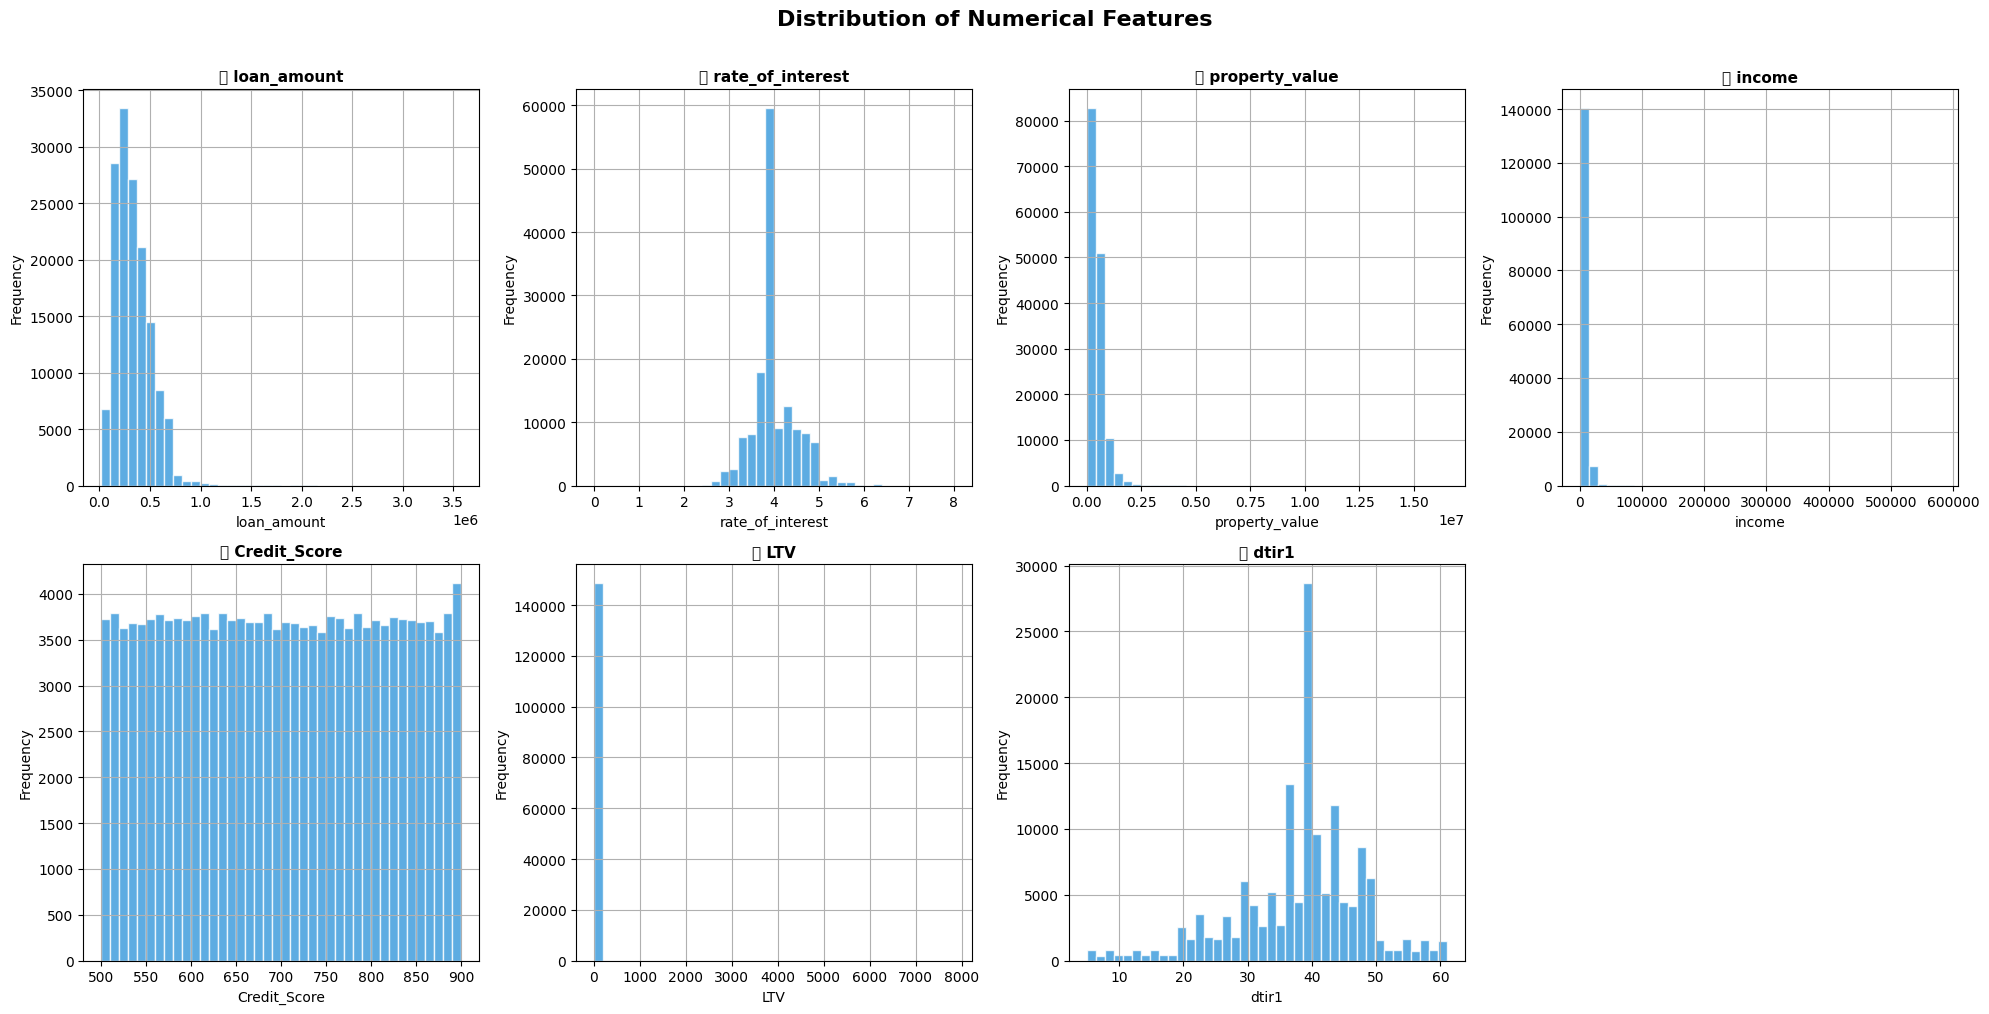

In [11]:
# Numerical features distribution
num_cols = ['loan_amount', 'rate_of_interest', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].dropna().hist(bins=40, ax=axes[i], color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'📊 {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5767/2308308241.py:16: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


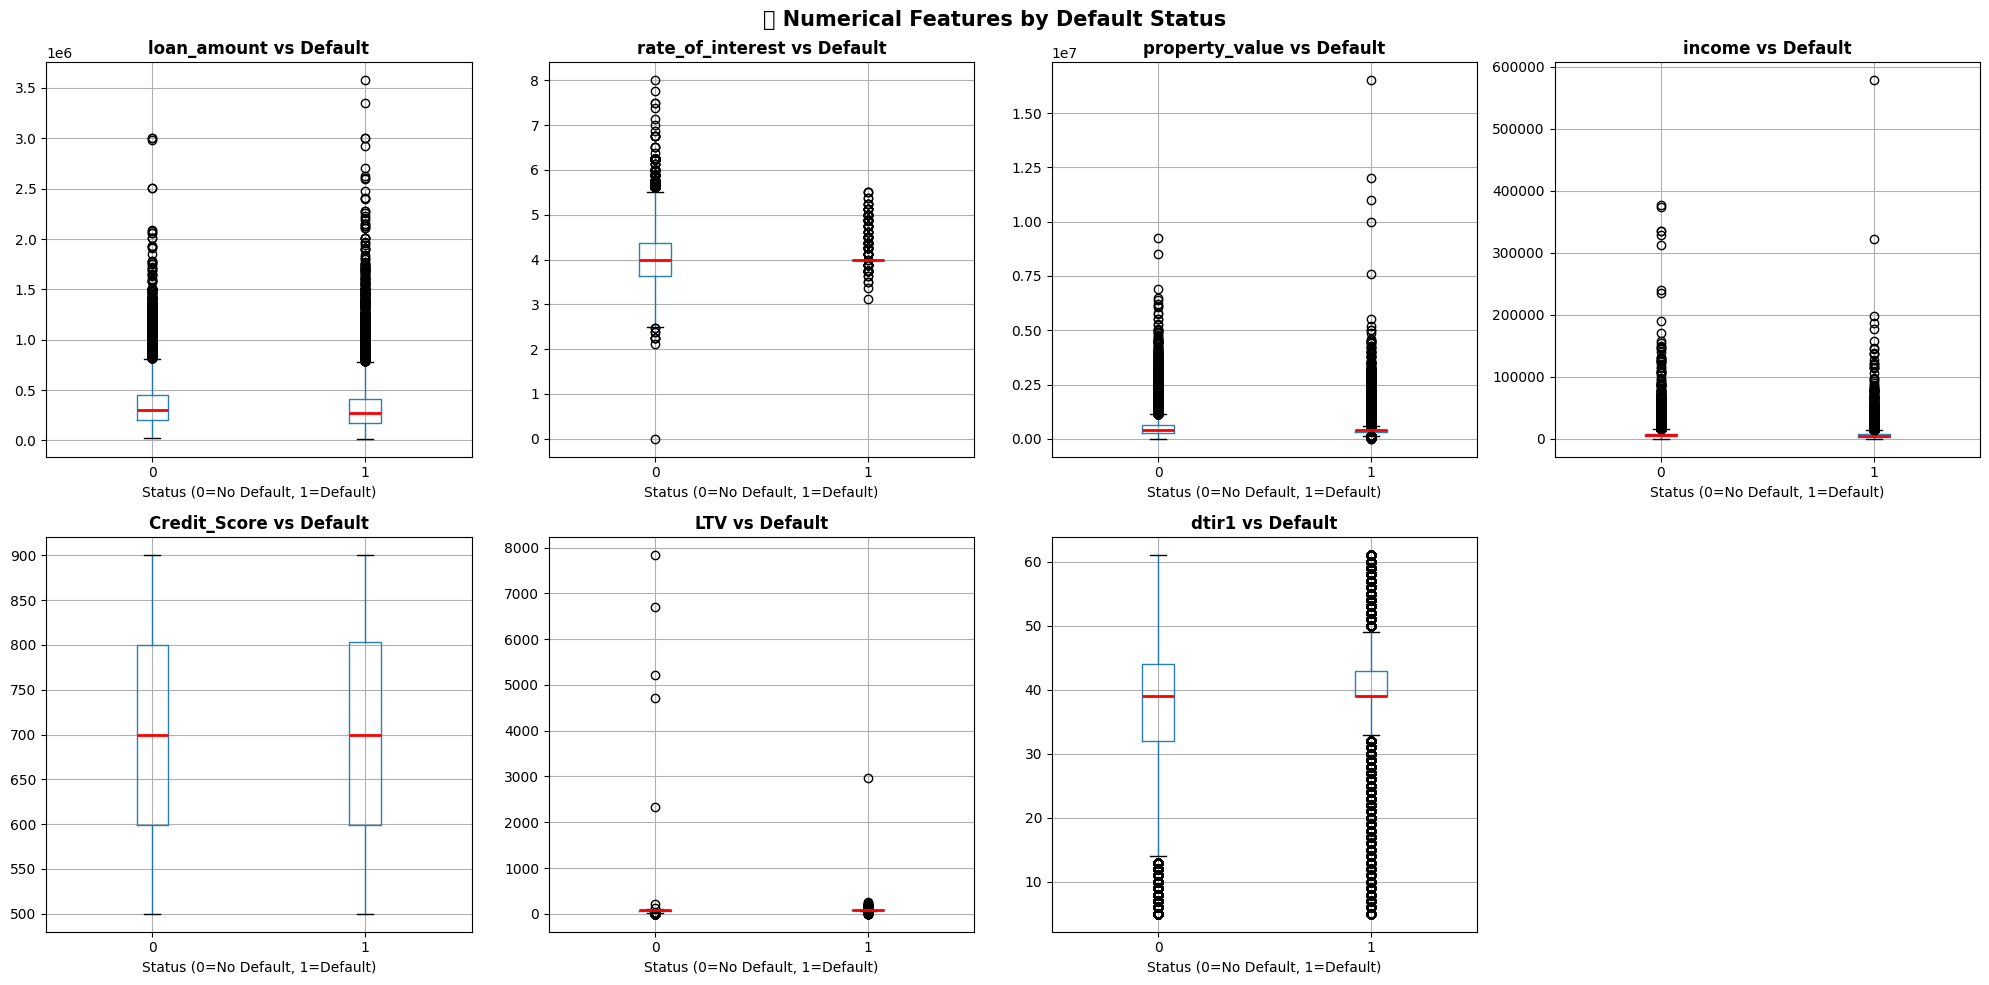

In [12]:
# Boxplots: Numerical features vs Status
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Status', ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} vs Default', fontweight='bold')
    axes[i].set_xlabel('Status (0=No Default, 1=Default)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📦 Numerical Features by Default Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5767/555674015.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


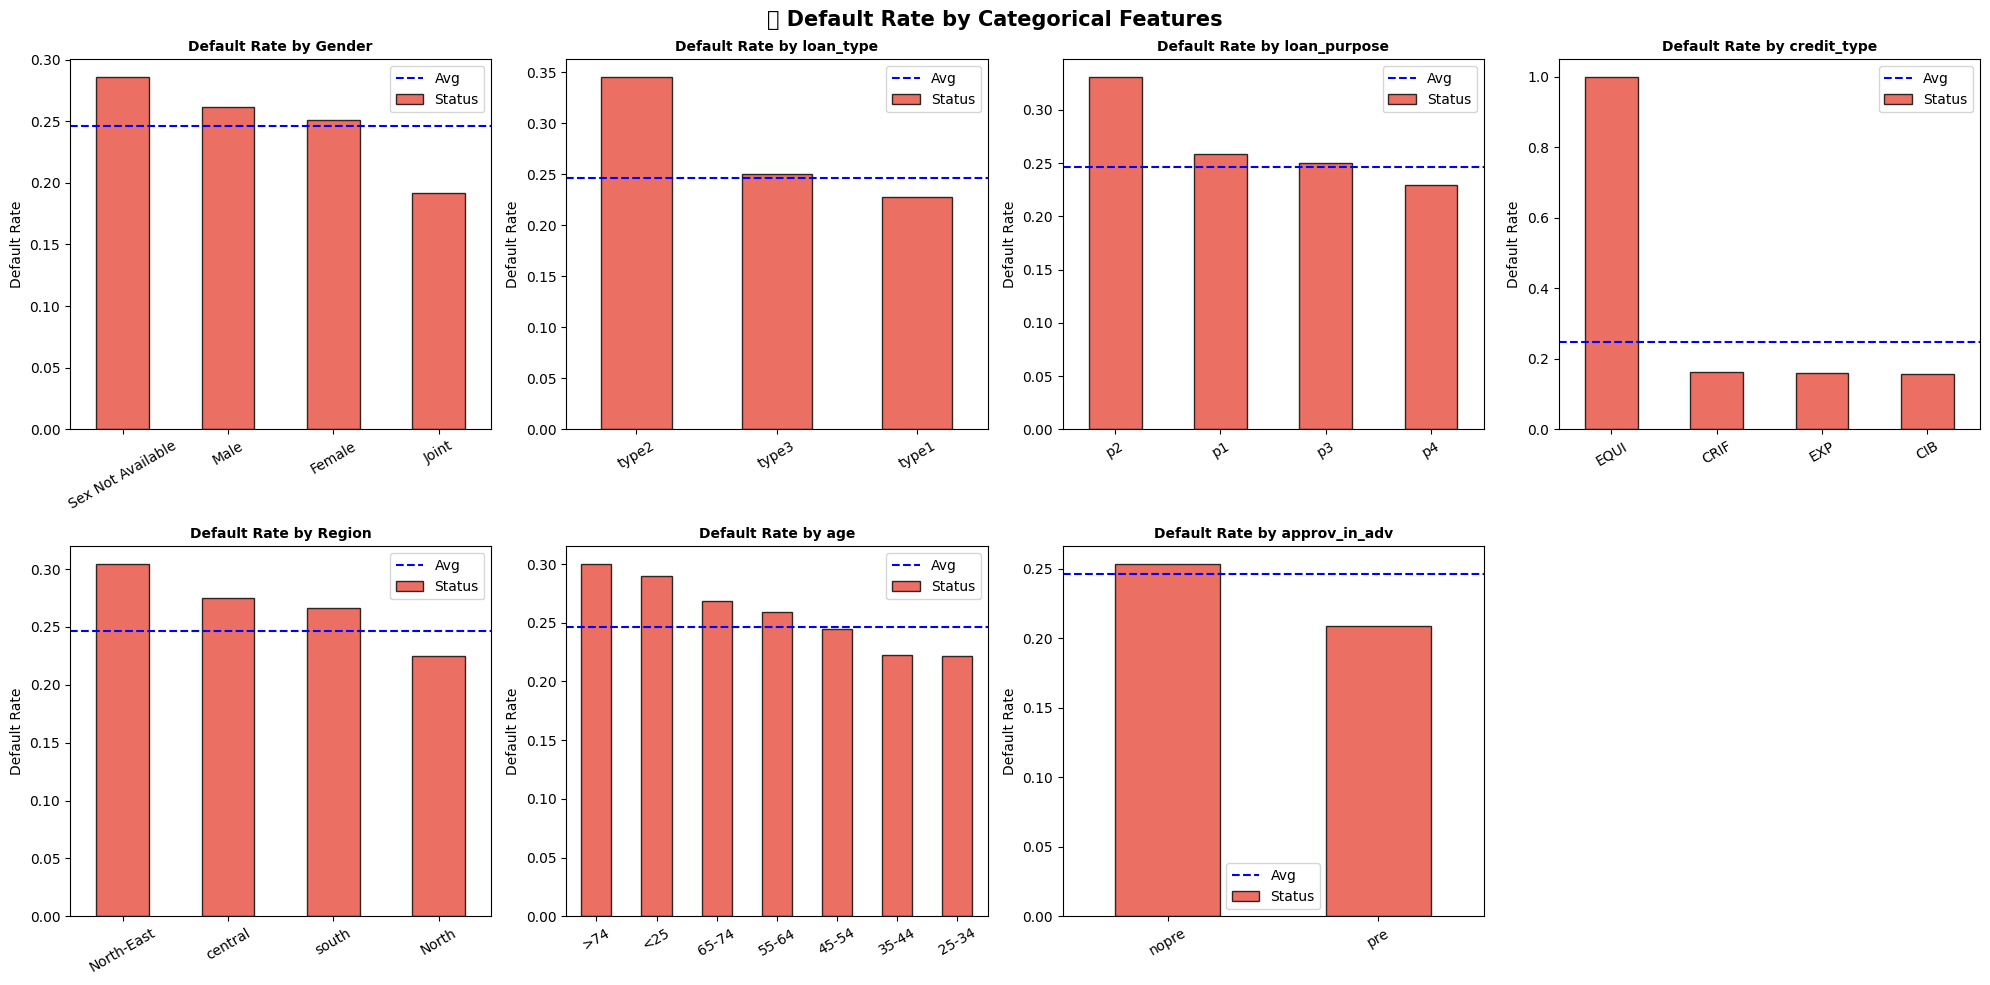

In [13]:
# Categorical features analysis
cat_cols = ['Gender', 'loan_type', 'loan_purpose', 'credit_type', 'Region', 'age', 'approv_in_adv']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['Status'].mean().sort_values(ascending=False)
    default_rate.plot(kind='bar', ax=axes[i], color='#e74c3c', alpha=0.8, edgecolor='black')
    axes[i].set_title(f'Default Rate by {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Default Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(df['Status'].mean(), color='blue', linestyle='--', linewidth=1.5, label='Avg')
    axes[i].legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📉 Default Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5767/3283839161.py:9: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


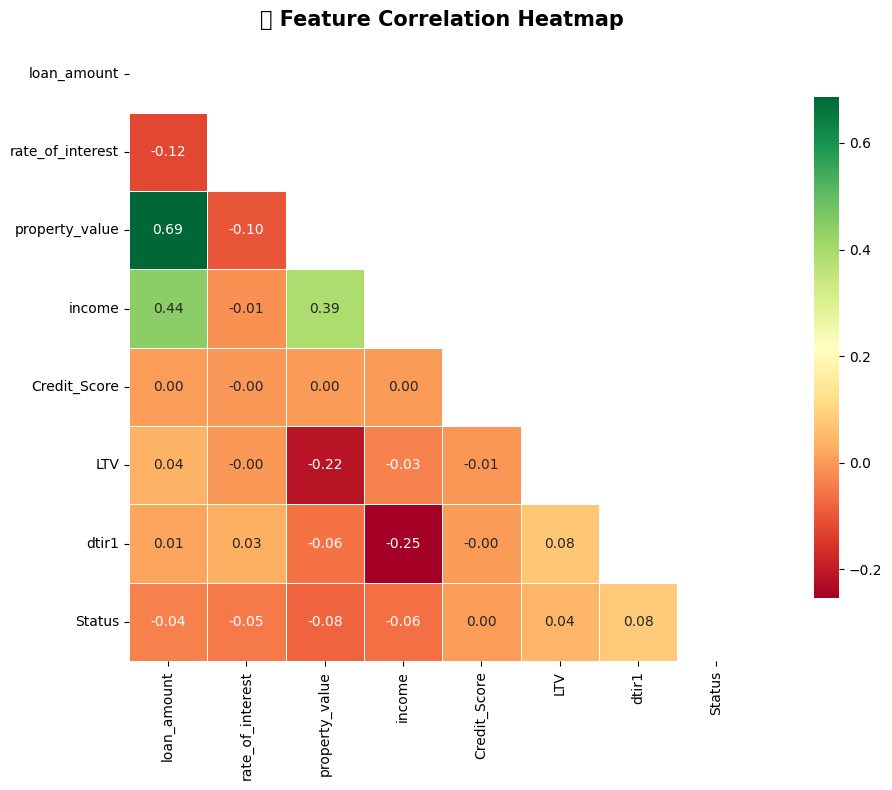

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_cols = df[num_cols + ['Status']].corr()
mask = np.triu(np.ones_like(corr_cols, dtype=bool))
sns.heatmap(corr_cols, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('🔥 Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
df_ml = df.copy()
df_ml.drop(columns=['ID', 'year'], inplace=True, errors='ignore')

In [16]:
# Target variable separate karo
X = df_ml.drop('Status', axis=1)
y = df_ml['Status']

In [17]:
X.shape

(148670, 31)

In [18]:
y.shape

(148670,)

In [19]:
# Categorical aur Numerical columns separate karo
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols_ml = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [20]:
num_cols_ml

['loan_amount',
 'rate_of_interest',
 'Interest_rate_spread',
 'Upfront_charges',
 'term',
 'property_value',
 'income',
 'Credit_Score',
 'LTV',
 'dtir1']

In [21]:
from sklearn.impute import SimpleImputer

# Numerical: median se fill karo
num_imputer = SimpleImputer(strategy='median')
X[num_cols_ml] = num_imputer.fit_transform(X[num_cols_ml])

# Categorical: most frequent value se fill karo
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [22]:
X.isnull().sum().sum()

np.int64(0)

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [25]:
X.shape

(148670, 31)

In [26]:
X.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,dtir1
0,0,3,0,0,0,0,0,1,116500.0,3.99,...,1740.0,3,758.0,0,0,1,98.728814,3,1,45.0
1,0,2,0,1,0,0,0,0,206500.0,3.99,...,4980.0,2,552.0,1,3,1,75.135870,0,1,39.0
2,0,2,1,0,0,0,0,1,406500.0,4.56,...,9480.0,3,834.0,0,1,1,80.019685,3,1,46.0
3,0,2,0,0,3,0,0,1,456500.0,4.25,...,11880.0,3,587.0,0,2,0,69.376900,0,1,42.0
4,0,1,1,0,0,0,0,1,696500.0,4.00,...,10440.0,1,602.0,1,0,0,91.886544,0,1,39.0


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
X_train.shape

(118936, 31)

In [30]:
y_test.shape

(29734,)

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [34]:
# Models define karo
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}
results = {}
print('🚀 Model training shuru ho raha hai...')
print('=' * 55)

🚀 Model training shuru ho raha hai...


In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

for name, model in models.items():
    print(f'⏳ Training: {name}...', end=' ')

    # Scaling use karo LR aur KNN ke liye
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
    }
    print(f'✅ Done! Accuracy: {results[name]["accuracy"]:.4f}')

print('=' * 55)
print('🎉 Sab models train ho gaye!')

⏳ Training: Logistic Regression... ✅ Done! Accuracy: 0.7848
⏳ Training: Decision Tree... ✅ Done! Accuracy: 1.0000
⏳ Training: Random Forest... ✅ Done! Accuracy: 1.0000
⏳ Training: Gradient Boosting... ✅ Done! Accuracy: 1.0000
⏳ Training: K-Nearest Neighbors... ✅ Done! Accuracy: 0.9075
🎉 Sab models train ho gaye!


In [36]:
# Results comparison table
comparison = pd.DataFrame({
    name: {
        'Accuracy':  f"{v['accuracy']:.4f}",
        'F1 Score':  f"{v['f1']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall':    f"{v['recall']:.4f}",
        'ROC-AUC':   f"{v['roc_auc']:.4f}",
    }
    for name, v in results.items()
}).T

print('📊 Model Comparison Table:')
print('=' * 75)
display(comparison.style.background_gradient(cmap='YlGn'))

📊 Model Comparison Table:


,Accuracy,F1 Score,Precision,Recall,ROC-AUC
Logistic Regression,0.7848,0.3763,0.6581,0.2635,0.7634
Decision Tree,1.0000,0.9999,1.0000,0.9999,0.9999
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,0.9999,1.0000,0.9999,1.0000
K-Nearest Neighbors,0.9075,0.8149,0.8037,0.8264,0.9590


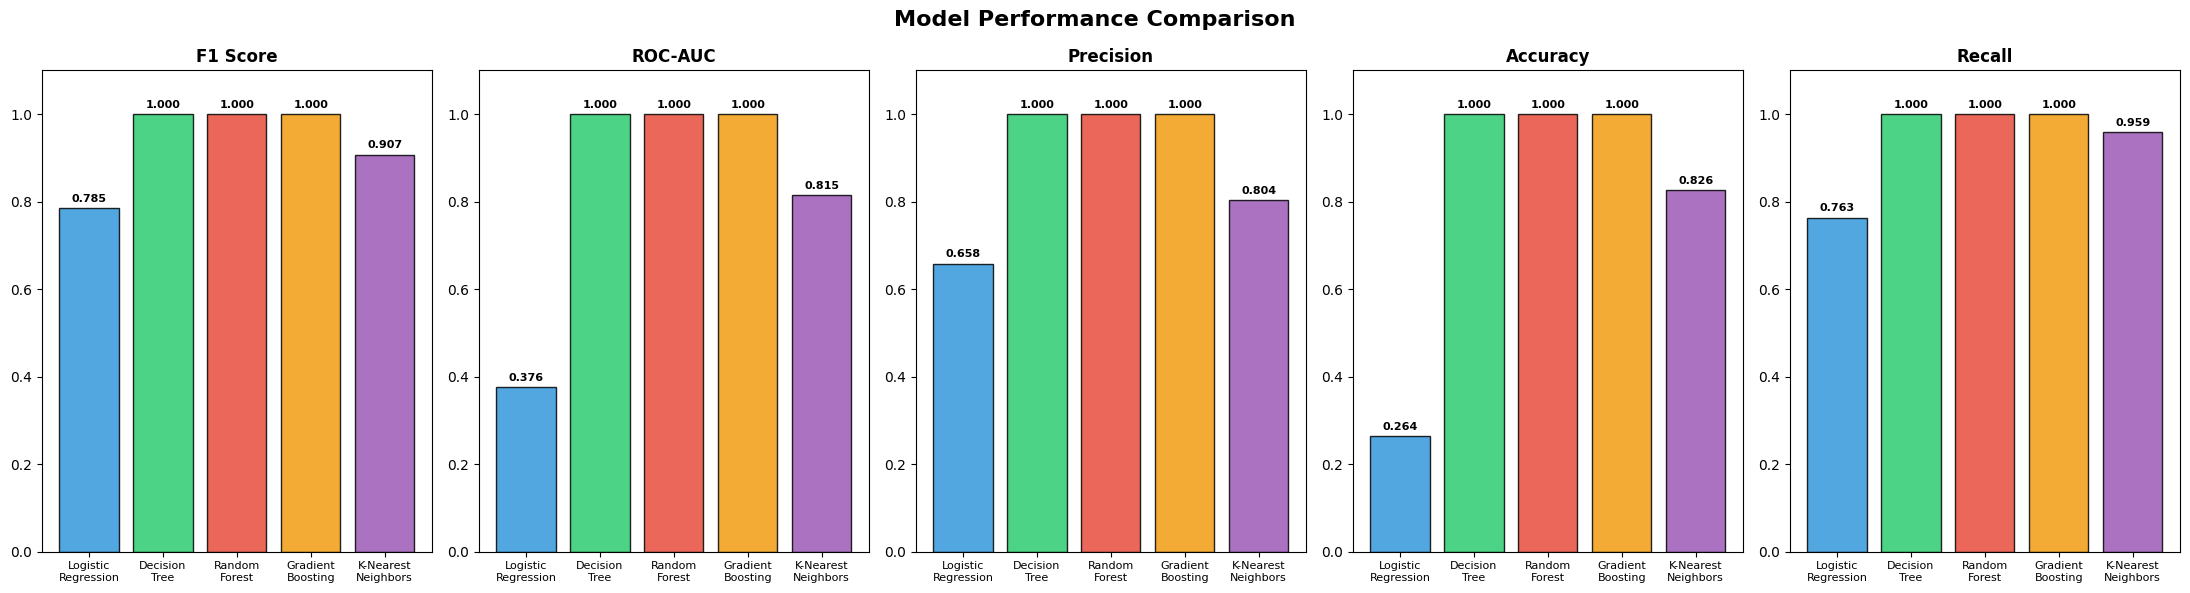

In [37]:
metrics = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
metric_labels = {'Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC'}
model_names = list(results.keys())
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
  vals = [results[name][metric] for name in model_names] # Fixed: Changed m to name
  bars = axes[i].bar(range(len(model_names)), vals, color = colors_bar, alpha = 0.85, edgecolor = 'black')
  axes[i].set_title(label, fontweight = 'bold', fontsize = 12)
  axes[i].set_xticks(range(len(model_names)))
  axes[i].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
  axes[i].set_ylim(0, 1.1) # Fixed: Changed 1,1 to 1.1
  for bar, val in zip(bars, vals):
    axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha = "center", va = 'bottom', fontsize = 8, fontweight = 'bold')

plt.suptitle("Model Performance Comparison", fontsize=16, fontweight='bold') # Fixed: Changed subtitle to suptitle
plt.tight_layout()
plt.show()

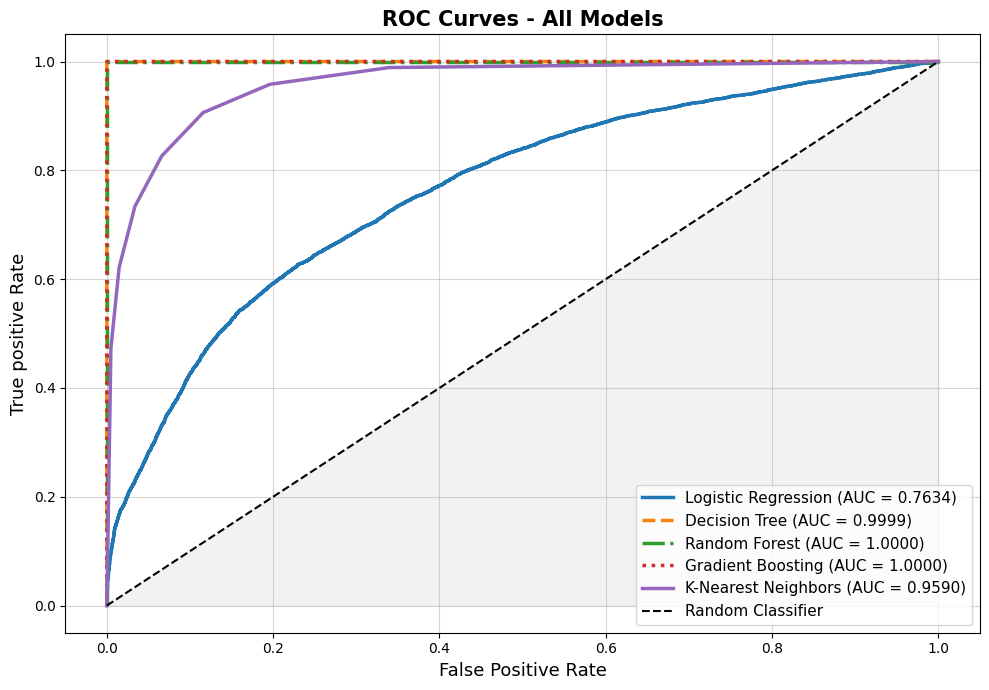

In [38]:
# ROC Curves
from sklearn.metrics import roc_curve
plt.figure(figsize=(10, 7))
line_styles = ['-', '--', '-.', ':', '-']

for i, (name, res) in enumerate(results.items()):
  fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
  plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.4f})", linewidth=2.5, linestyle=line_styles[i])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
plt.xlabel('False Positive Rate', fontsize = 13)
plt.ylabel('True positive Rate', fontsize=13)
plt.title('ROC Curves - All Models', fontsize = 15, fontweight = 'bold')
plt.legend(loc='lower right', fontsize = 11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_5767/370531215.py:20: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5767/370531215.py:20: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python

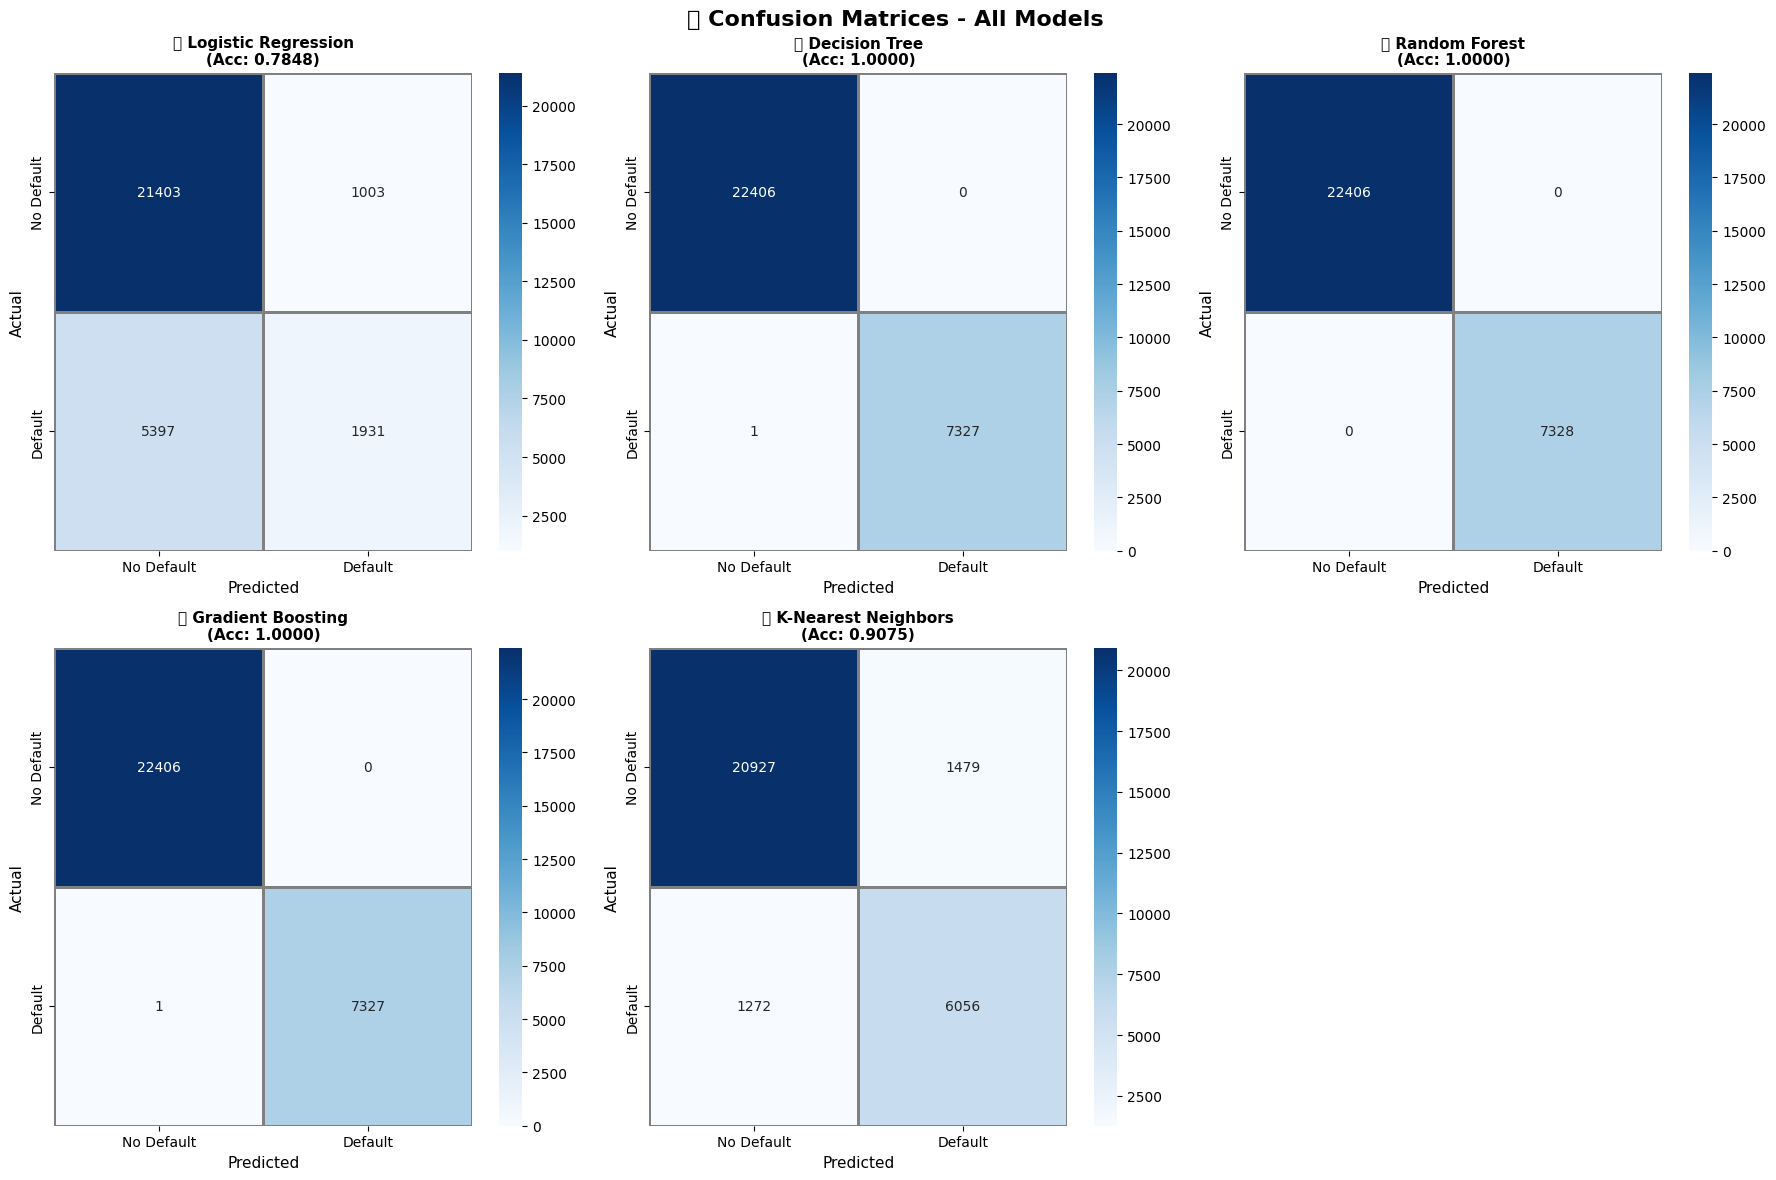

In [39]:
from sklearn.metrics import confusion_matrix
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'],
                linewidths=1, linecolor='gray')
    axes[i].set_title(f'🔢 {name}\n(Acc: {res["accuracy"]:.4f})',
                     fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=11)
    axes[i].set_xlabel('Predicted', fontsize=11)

axes[-1].set_visible(False)

plt.suptitle('🟦 Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import classification_report
# Best model detailed classification report
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_res = results[best_model_name]

print(f'🏆 Best Model: {best_model_name}')
print(f'   ROC-AUC:  {best_res["roc_auc"]:.4f}')
print(f'   Accuracy: {best_res["accuracy"]:.4f}')
print()
print('📊 Detailed Classification Report:')
print('-' * 50)
print(classification_report(y_test, best_res['y_pred'],
                           target_names=['No Default', 'Default']))

🏆 Best Model: Random Forest
   ROC-AUC:  1.0000
   Accuracy: 1.0000

📊 Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00     22406
     Default       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



/tmp/ipykernel_5767/311673445.py:21: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


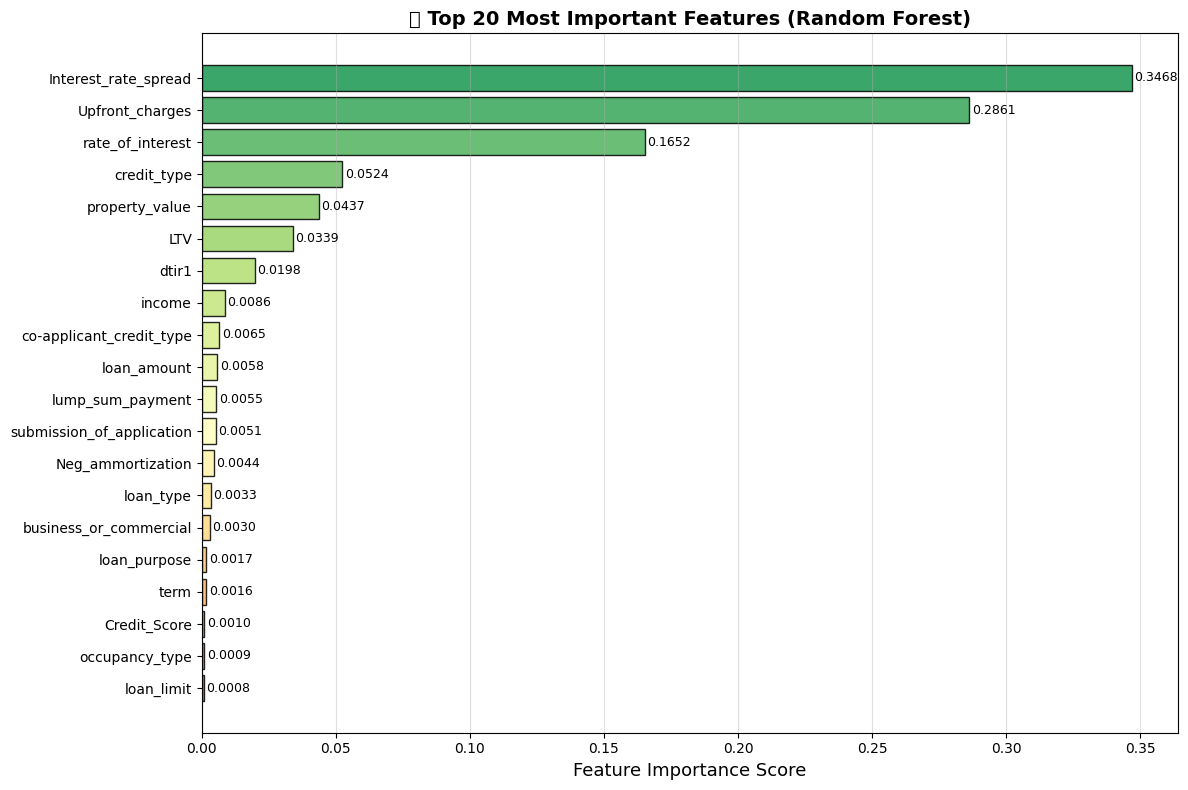

In [41]:
# Random Forest feature importance
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(feature_importance['Feature'][::-1],
                feature_importance['Importance'][::-1],
                color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feature_importance))),
                edgecolor='black', alpha=0.85)

for bar, val in zip(bars, feature_importance['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Feature Importance Score', fontsize=13)
plt.title('🌟 Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

🔄 5-Fold Cross Validation (Random Forest):
---------------------------------------------
Fold Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Mean AUC:    1.0000 ± 0.0000


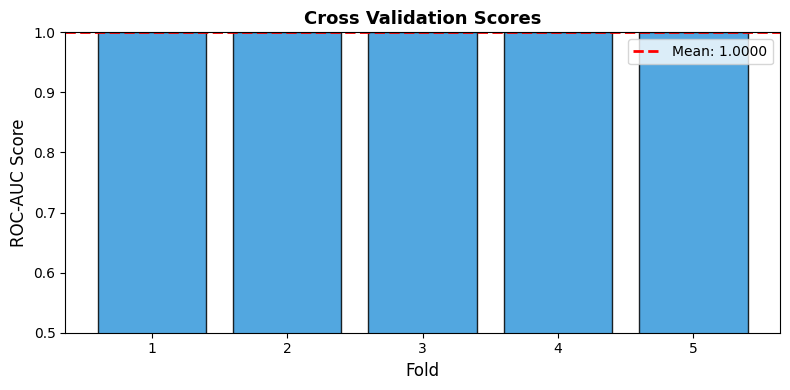

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Cross Validation Score
print('🔄 5-Fold Cross Validation (Random Forest):')
print('-' * 45)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'Fold Scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean AUC:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='#3498db', edgecolor='black', alpha=0.85)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Cross Validation Scores', fontsize=13, fontweight='bold')
plt.legend()
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [43]:
# Test sample pe prediction
sample = X_test.iloc[:5]
best_m = results[best_model_name]['model']

if best_model_name in ['Logistic Regression', 'K-Nearest Neighbors']:
    sample_scaled = scaler.transform(sample)
    preds = best_m.predict(sample_scaled)
    probs = best_m.predict_proba(sample_scaled)[:, 1]
else:
    preds = best_m.predict(sample)
    probs = best_m.predict_proba(sample)[:, 1]

pred_df = pd.DataFrame({
    'Actual':            y_test.iloc[:5].values,
    'Predicted':         preds,
    'Default Prob (%)':  (probs * 100).round(2),
    'Correct?':          ['✅' if a == p else '❌' for a, p in zip(y_test.iloc[:5].values, preds)]
})

print(f'🔮 {best_model_name} - Sample Predictions:')
display(pred_df)

🔮 Random Forest - Sample Predictions:


,Actual,Predicted,Default Prob (%),Correct?
0,0,0,0.0,✅
1,0,0,0.0,✅
2,0,0,0.0,✅
3,0,0,0.0,✅
4,0,0,0.0,✅


In [44]:
import joblib
joblib.dump(results['K-Nearest Neighbors']['model'], 'best_model_lone_prediction.pkl')

['best_model_lone_prediction.pkl']